[[1 1]
 [0 1]]
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



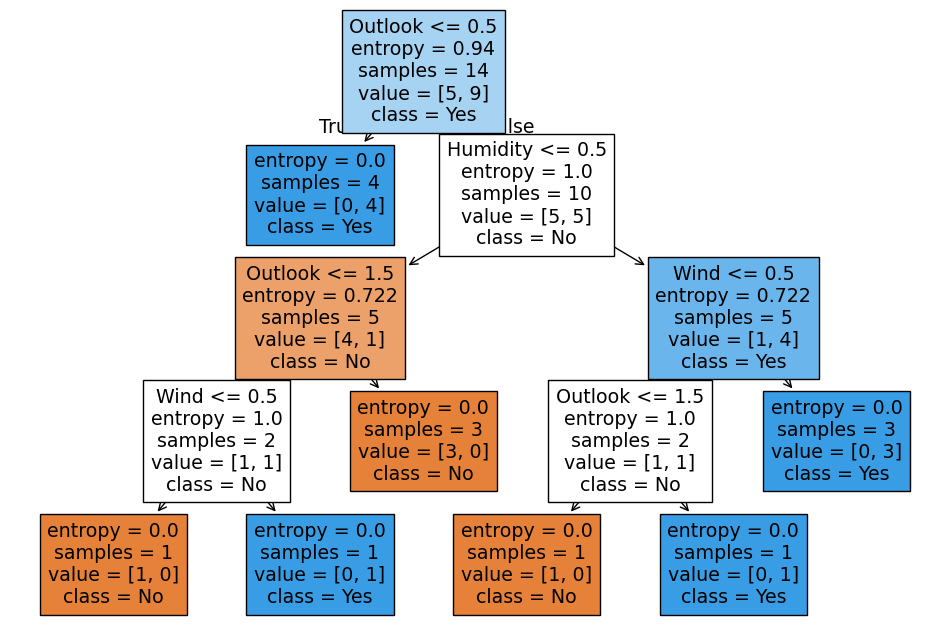

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import preprocessing
import matplotlib.pyplot as plt

# Dataset
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Mild','Hot','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

# Convert categorical data into numbers
le = preprocessing.LabelEncoder()

for column in df.columns:
    df[column] = le.fit_transform(df[column])

# Features and Target
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier()
classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = classifier.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


# Train Decision Tree
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X, y)

# Plot the tree
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

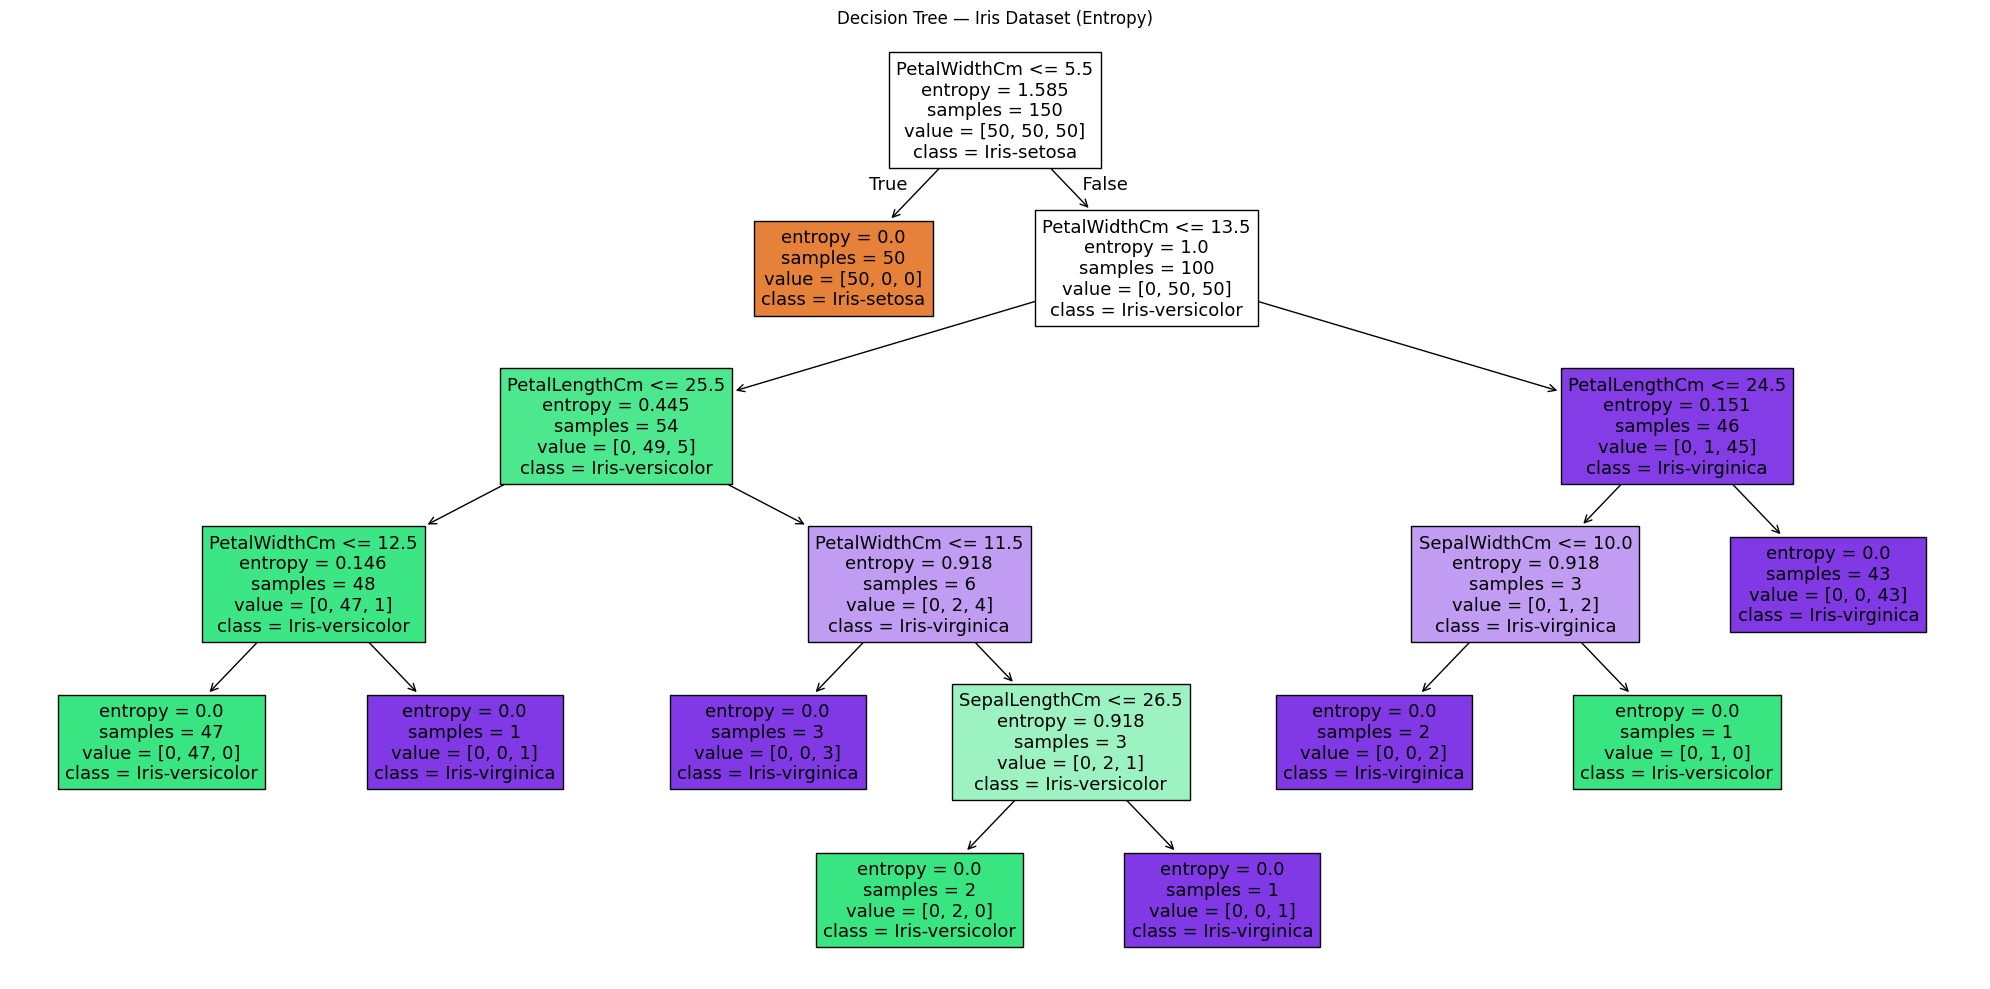

Training Accuracy: 100.0 %


In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import preprocessing
import matplotlib.pyplot as plt

# Load the Iris CSV file

data = pd.read_csv('Iris.csv')
df = pd.DataFrame(data)

df = df.drop('Id', axis=1)

class_names = sorted(data['Species'].unique())

le = preprocessing.LabelEncoder()

for column in df.columns:
    df[column] = le.fit_transform(df[column])

X = df.drop('Species', axis=1)
Y = df['Species']

model = DecisionTreeClassifier(criterion='entropy')
model.fit(X, Y)

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=class_names,  
    filled=True
)
plt.title("Decision Tree — Iris Dataset (Entropy)")
plt.tight_layout()
plt.savefig('iris_tree.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training Accuracy:", round(model.score(X, Y) * 100, 2), "%")